In [1]:
import pandas as pd

df = pd.read_csv("hospital_patients_clean.csv")
df.shape


(4947, 7)

In [2]:
import pandas as pd
import sqlite3


In [3]:
conn = sqlite3.connect(":memory:")
df.to_sql("hospital", conn, index=False, if_exists="replace")


4947

In [4]:
pd.read_sql("SELECT COUNT(*) AS n_rows FROM hospital", conn)


,n_rows
0,4947


In [5]:
df["AdmissionDate"] = pd.to_datetime(df["AdmissionDate"], errors="coerce")
df["DischargeDate"] = pd.to_datetime(df["DischargeDate"], errors="coerce")
df["LengthOfStay"] = (df["DischargeDate"] - df["AdmissionDate"]).dt.days
df[["AdmissionDate","DischargeDate","LengthOfStay"]].head()


,AdmissionDate,DischargeDate,LengthOfStay
0,2024-03-23,2024-03-29,6
1,2024-08-01,2024-08-07,6
2,2024-11-16,2024-11-23,7
3,2025-07-05,2025-07-10,5
4,2023-08-30,2023-08-31,1


In [6]:
df["LengthOfStay"].isna().sum()


np.int64(0)

In [7]:
df["LengthOfStay"].min(), df["LengthOfStay"].max()


(-5, 10)

In [8]:
(df["LengthOfStay"] < 0).sum()


np.int64(148)

In [9]:
df.loc[df["LengthOfStay"] < 0, ["AdmissionDate", "DischargeDate", "LengthOfStay"]].head(10)


,AdmissionDate,DischargeDate,LengthOfStay
22,2026-01-13,2026-01-08,-5
25,2024-06-04,2024-05-30,-5
40,2023-07-25,2023-07-20,-5
46,2024-01-12,2024-01-07,-5
103,2025-06-25,2025-06-20,-5
115,2024-01-21,2024-01-16,-5
182,2024-05-01,2024-04-26,-5
198,2024-11-26,2024-11-21,-5
199,2023-09-13,2023-09-08,-5
209,2023-11-17,2023-11-12,-5


In [10]:
df.loc[df["LengthOfStay"] < 0, ["AdmissionDate", "DischargeDate", "LengthOfStay"]].sort_values("LengthOfStay").head(10)


,AdmissionDate,DischargeDate,LengthOfStay
22,2026-01-13,2026-01-08,-5
3277,2025-05-07,2025-05-02,-5
3335,2025-10-05,2025-09-30,-5
3381,2025-02-02,2025-01-28,-5
3396,2025-10-06,2025-10-01,-5
3431,2024-12-01,2024-11-26,-5
3435,2024-03-30,2024-03-25,-5
3266,2025-10-17,2025-10-12,-5
3502,2025-07-30,2025-07-25,-5
3564,2023-07-09,2023-07-04,-5


In [11]:
mask = df["LengthOfStay"] < 0
df.loc[mask, ["AdmissionDate", "DischargeDate"]] = df.loc[mask, ["DischargeDate", "AdmissionDate"]].values
df["LengthOfStay"] = (df["DischargeDate"] - df["AdmissionDate"]).dt.days
df["LengthOfStay"].min(), df["LengthOfStay"].max(), (df["LengthOfStay"] < 0).sum()


(1, 10, np.int64(0))

In [12]:
df.to_sql("hospital", conn, index=False, if_exists="replace")
pd.read_sql("SELECT MIN(LengthOfStay) AS min_los, MAX(LengthOfStay) AS max_los, COUNT(*) AS n FROM hospital", conn)


,min_los,max_los,n
0,1,10,4947


In [13]:
pd.read_sql("""
SELECT
  LengthOfStay,
  COUNT(*) AS cnt
FROM hospital
GROUP BY LengthOfStay
ORDER BY LengthOfStay
""", conn)


,LengthOfStay,cnt
0,1,534
1,2,456
2,3,493
3,4,450
4,5,620
5,6,459
6,7,509
7,8,492
8,9,455
9,10,479


In [14]:
pd.read_sql("""
SELECT
  Diagnosis,
  AVG(LengthOfStay) AS avg_los,
  COUNT(*) AS n
FROM hospital
GROUP BY Diagnosis
ORDER BY avg_los DESC
""", conn)


,Diagnosis,avg_los,n
0,ATRIAL FIBRILLATION,6.695652,23
1,CHRONIC KIDNEY DISEASE,6.157895,19
2,MYOCARDIAL INFARCTION,6.120000,25
3,CHOLELITHIASIS,6.080000,25
4,ASTHMA,6.038462,26
5,OSTEOARTHRITIS,6.000000,22
6,ACUTE BRONCHITIS,5.750000,20
7,Atrial Fibrillation,5.655280,322
8,Myocardial Infarction,5.601375,291
9,Asthma,5.591195,318


In [15]:
df["Diagnosis"] = df["Diagnosis"].str.strip().str.title()


In [16]:
df.to_sql("hospital", conn, index=False, if_exists="replace")


4947

In [17]:
pd.read_sql("""
SELECT
  Diagnosis,
  AVG(LengthOfStay) AS avg_los,
  COUNT(*) AS n
FROM hospital
GROUP BY Diagnosis
ORDER BY avg_los DESC
""", conn)


,Diagnosis,avg_los,n
0,Atrial Fibrillation,5.724638,345
1,Myocardial Infarction,5.642405,316
2,Asthma,5.625000,344
3,Urinary Tract Infection,5.538674,362
4,Influenza,5.485981,321
5,Unknown,5.445860,314
6,Pneumonia,5.421569,306
7,Gastroenteritis,5.415094,318
8,Hypertension,5.406940,317
9,Type 2 Diabetes,5.369492,295


In [18]:
pd.read_sql("""
SELECT
  Age,
  AVG(LengthOfStay) AS avg_los,
  COUNT(*) AS n
FROM hospital
GROUP BY Age
ORDER BY Age
""", conn)


,Age,avg_los,n
0,0.0,5.057692,52
1,1.0,6.320755,53
2,2.0,5.271186,59
3,3.0,5.111111,36
4,4.0,6.224138,58
...,...,...,...
91,91.0,5.419355,31
92,92.0,5.413043,46
93,93.0,5.387097,62
94,94.0,5.536585,41


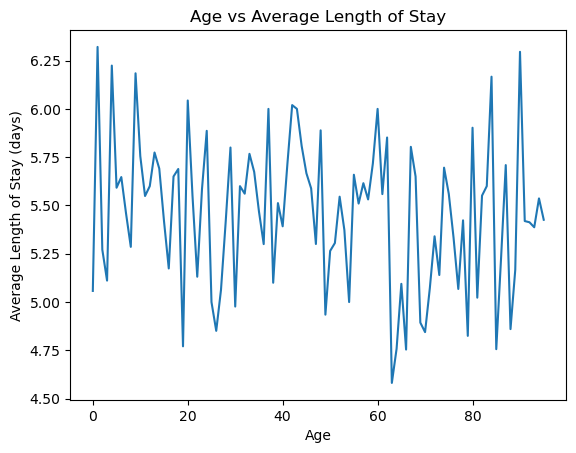

In [19]:
import matplotlib.pyplot as plt

age_los = pd.read_sql("""
SELECT
  Age,
  AVG(LengthOfStay) AS avg_los
FROM hospital
GROUP BY Age
ORDER BY Age
""", conn)

plt.figure()
plt.plot(age_los["Age"], age_los["avg_los"])
plt.xlabel("Age")
plt.ylabel("Average Length of Stay (days)")
plt.title("Age vs Average Length of Stay")
plt.show()


In [20]:
pd.read_sql("""
SELECT
  CASE
    WHEN Age < 18 THEN '0-17'
    WHEN Age BETWEEN 18 AND 40 THEN '18-40'
    WHEN Age BETWEEN 41 AND 65 THEN '41-65'
    ELSE '65+'
  END AS AgeGroup,
  AVG(LengthOfStay) AS avg_los,
  COUNT(*) AS n
FROM hospital
GROUP BY AgeGroup
ORDER BY AgeGroup
""", conn)


,AgeGroup,avg_los,n
0,0-17,5.604236,897
1,18-40,5.435185,1080
2,41-65,5.458141,1517
3,65+,5.358568,1453


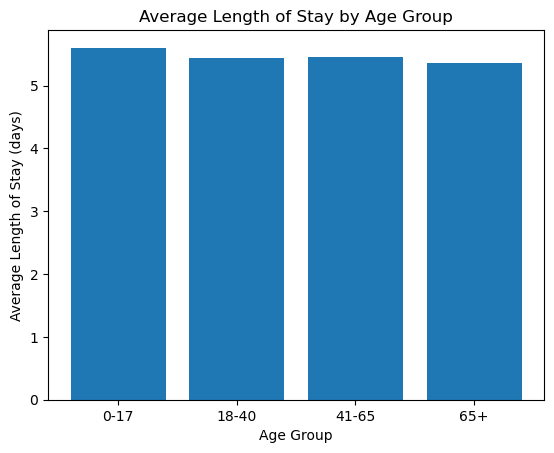

In [21]:
import matplotlib.pyplot as plt

age_group_los = pd.read_sql("""
SELECT
  CASE
    WHEN Age < 18 THEN '0-17'
    WHEN Age BETWEEN 18 AND 40 THEN '18-40'
    WHEN Age BETWEEN 41 AND 65 THEN '41-65'
    ELSE '65+'
  END AS AgeGroup,
  AVG(LengthOfStay) AS avg_los
FROM hospital
GROUP BY AgeGroup
ORDER BY AgeGroup
""", conn)

plt.figure()
plt.bar(age_group_los["AgeGroup"], age_group_los["avg_los"])
plt.xlabel("Age Group")
plt.ylabel("Average Length of Stay (days)")
plt.title("Average Length of Stay by Age Group")
plt.show()


In [22]:
pd.read_sql("""
SELECT
  Diagnosis,
  CASE
    WHEN Age < 18 THEN '0-17'
    WHEN Age BETWEEN 18 AND 40 THEN '18-40'
    WHEN Age BETWEEN 41 AND 65 THEN '41-65'
    ELSE '65+'
  END AS AgeGroup,
  AVG(LengthOfStay) AS avg_los,
  COUNT(*) AS n
FROM hospital
GROUP BY Diagnosis, AgeGroup
HAVING n > 30
ORDER BY Diagnosis, AgeGroup
""", conn)


,Diagnosis,AgeGroup,avg_los,n
0,Acute Bronchitis,0-17,4.875000,64
1,Acute Bronchitis,18-40,5.067416,89
2,Acute Bronchitis,41-65,5.319149,94
3,Acute Bronchitis,65+,5.680851,94
4,Asthma,0-17,5.193548,62
5,Asthma,18-40,5.435897,78
6,Asthma,41-65,6.316327,98
7,Asthma,65+,5.377358,106
8,Atrial Fibrillation,0-17,5.538462,65
9,Atrial Fibrillation,18-40,5.933333,90


In [23]:
df.to_csv("hospital_patients_clean.csv", index=False)


In [24]:
pd.read_csv("hospital_patients_clean.csv").shape


(4947, 8)

In [25]:
df["Diagnosis"].value_counts().loc[lambda x: x.index.str.contains("Asthma")]


Diagnosis
Asthma    344
Name: count, dtype: int64